## Analysis of the simulations output



Analysis of the files obtained in JWST server, using 450 combinations of parameters.

- Tmax = 5000 generations
- Number of replicates = 10000 replicates (one round)
- Size of array = 10 spacers

In [66]:
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/"
files = os.listdir(folder_path)
target_files = [
    "OutputFile_0.10_0.00_0.50.txt",
    "OutputFile_0.77_0.00_0.50.txt",
    "OutputFile_0.10_5.00_0.50.txt",
    "OutputFile_0.77_5.00_0.50.txt",
    "OutputFile_0.10_20.00_0.50.txt",
    "OutputFile_0.77_20.00_0.50.txt"

]
file_paths = [os.path.join(folder_path, f) for f in files if f in target_files]
data_dict = {file_path: load_file(file_path) for file_path in file_paths}
#print(selected_files)

In [45]:
import glob
import pandas as pd
import numpy as np

def load_file(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5) 
    return data

# Specify the folder path and file pattern
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/"
file_pattern = r"OutputFile_*_(0.00|5.00|20.00)_0.50.txt" ##No hemos hecho para a=1
# Get a list of all files matching the pattern
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Verify data
#for file, data in data_dict.items():
#    print(f"Data for {file}:\n", data)

In [65]:
columns = next(iter(data_dict.values())).columns  # Get columns from the first DataFrame(with next and iter)
columns = columns[0:6]
print(columns)

Index(['beta', 'age', 'efficacy', 'fitness', 'endemicBeta', 'epidemicBeta'], dtype='object')


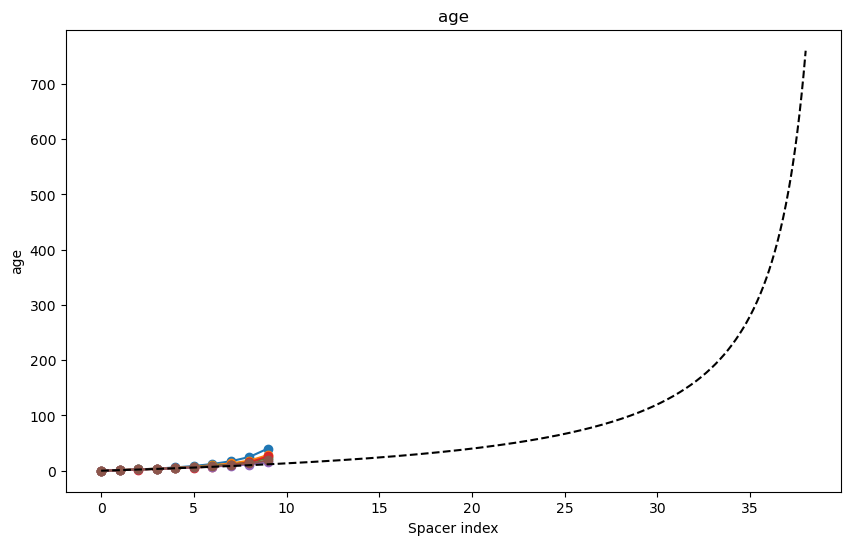

In [52]:
import matplotlib.pyplot as plt
for column in columns:
    if column == 'age': # maybe this line could be better in terms of computational requirement
        plt.figure(figsize=(10, 6))
    
        # Loop over each file and plot the column's data
        for file_name, data in data_dict.items():
            plt.plot(data.index, data[column], marker='o')
        x_vals = np.linspace(0, 38, 1000)  
        y_vals = x_vals / (1 - x_vals/40)         
        plt.plot(x_vals, y_vals, linestyle='--', color='black', label='Límite: 1/y = 1/x - 0.025')
        #plt.xlim(20, 30)
        #plt.ylim(10, 150)
        plt.title(f'{column}')        
        plt.xlabel('Spacer index')
        plt.ylabel(f'{column}')

        # Show the log-log plot for the current column
        plt.show()

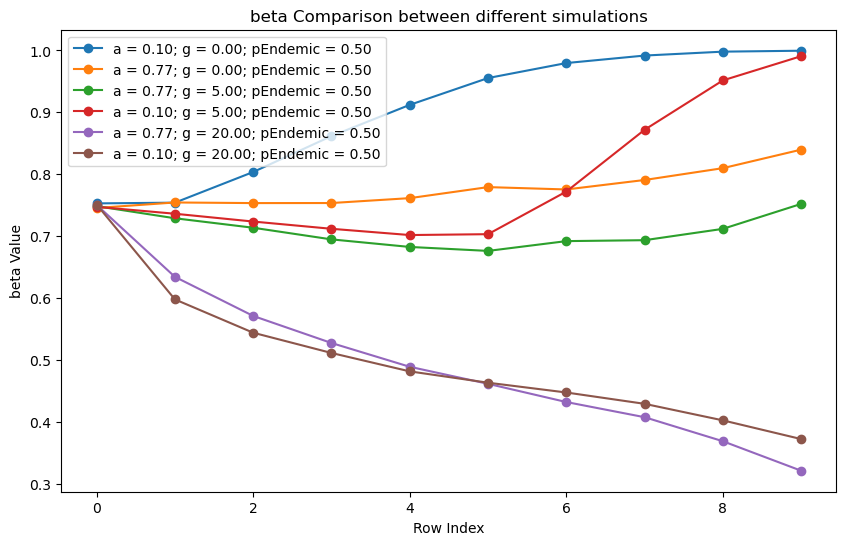

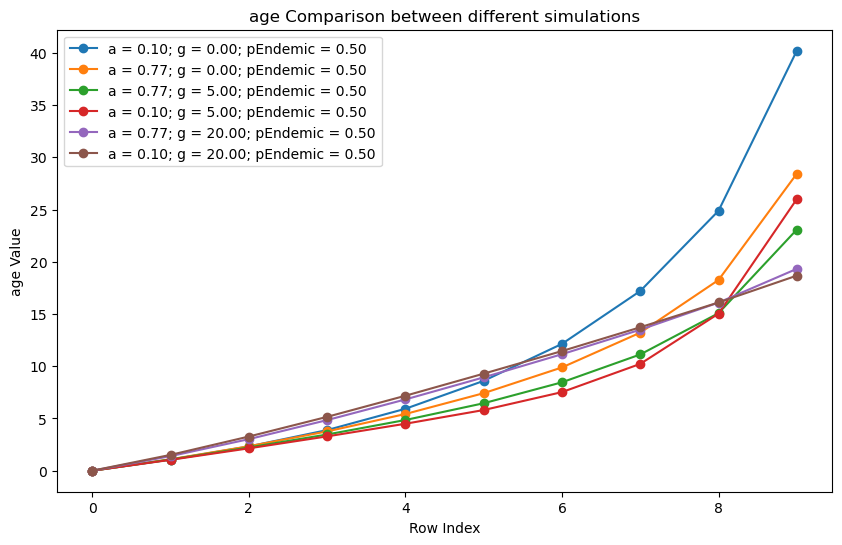

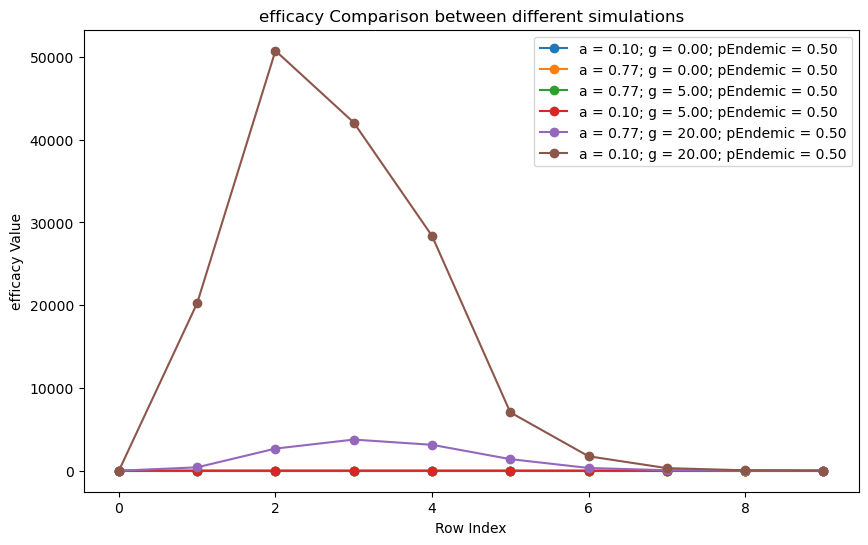

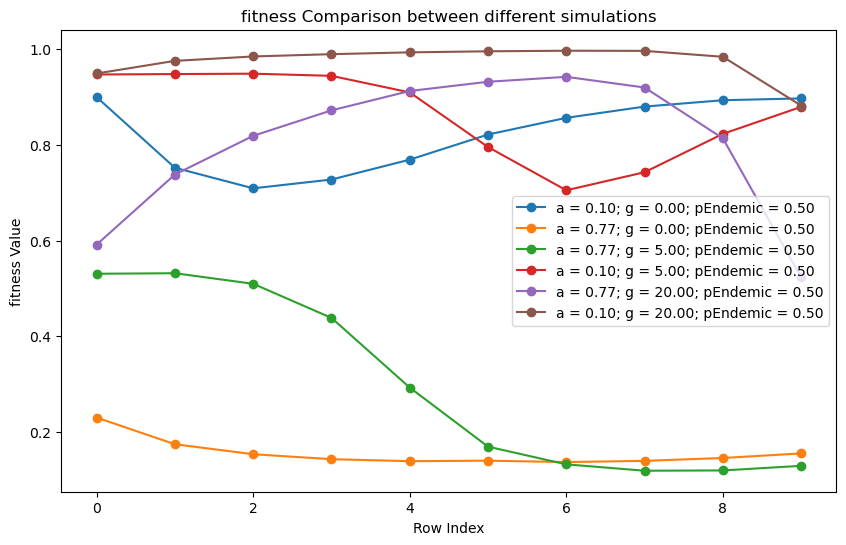

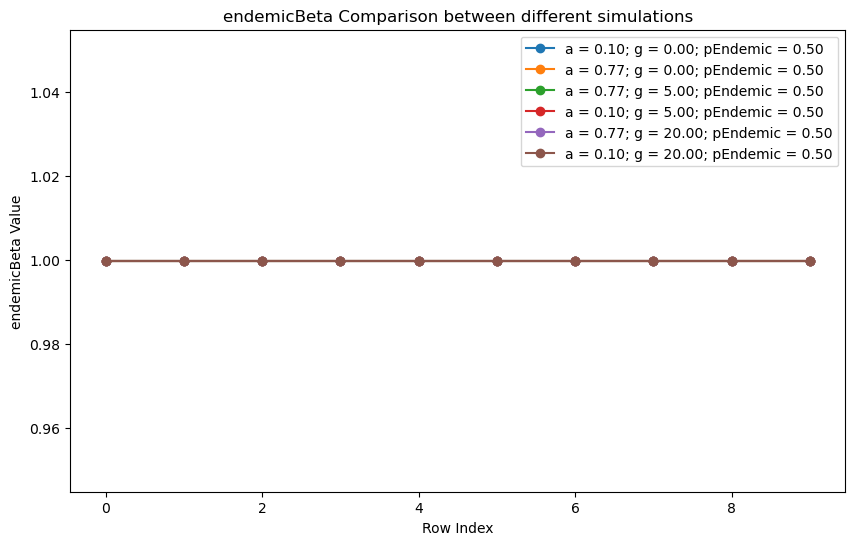

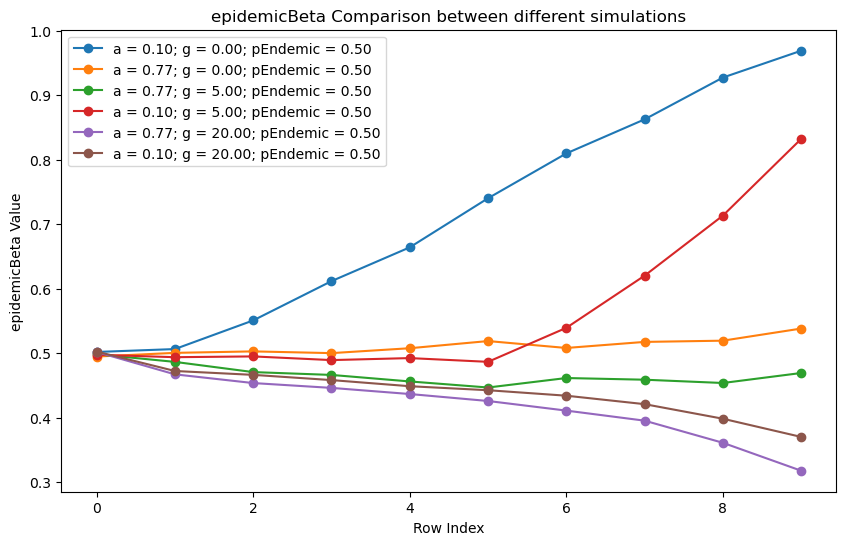

In [71]:
import matplotlib.pyplot as plt

# Extract parameter information from filenames for labeling
def extract_label(file_name):
    # Extract meaningful parts from the filename (modify based on your filename pattern)
    params = file_name.split("/")[-1].split("_")
    a = params[1]
    g = params[2]
    p_endemic = params[3].replace(".txt", "")
    return f'a = {a}; g = {g}; pEndemic = {p_endemic}'

# Loop over each column
for column in columns:
    plt.figure(figsize=(10, 6))
    
    # Loop over each file and plot the column's data
    for file_name, data in data_dict.items():
        label = extract_label(file_name)
        plt.plot(data.index, data[column], label=label, marker='o')
    
    # Adding title and labels
    plt.title(f'{column} Comparison between different simulations')
    plt.xlabel('Row Index')
    plt.ylabel(f'{column} Value')
    plt.legend()
    # Show the plot for the current column
    plt.show()
    

### Ratio between maxima, position of minimum and FWHM (Full Width at Half Maximum)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob
import numpy as np
import math 
import os


In [28]:
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/"
files = os.listdir(folder_path)
target_files = [
    "OutputFile_0.10_0.00_0.50.txt",
    "OutputFile_0.10_10.00_0.50.txt",
    "OutputFile_0.77_0.00_0.50.txt",
    "OutputFile_0.77_10.00_0.50.txt"
]
file_paths = [os.path.join(folder_path, f) for f in files if f in target_files]

#print(selected_files)

In [29]:
# Linear interpolation to find the index corresponding to the midpoint value
def find_interpolated_index(x_values, y_values, midpoint_value):
    # Perform linear interpolation to find the corresponding index
    for i in range(len(y_values) - 1):
        if (y_values[i] <= midpoint_value <= y_values[i + 1]) or (y_values[i] >= midpoint_value >= y_values[i + 1]):
            x_left = x_values[i]
            x_right = x_values[i + 1]
            y_left = y_values[i]
            y_right = y_values[i + 1]
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

def find_interpolated_index_reverse(x_values, y_values, midpoint_value):
    for i in range(len(y_values) - 1, 0, -1):
        if (y_values[i] <= midpoint_value <= y_values[i - 1]) or (y_values[i] >= midpoint_value >= y_values[i - 1]):
            x_right = x_values[i]
            x_left = x_values[i - 1]
            y_right = y_values[i]
            y_left = y_values[i - 1]
            
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.10_0.00_0.50.txt
  Minpoint: 2, Value: 0.7093
  Max Left: 0, Value Max Left: 0.9
  Max Right: 9, Value Max Right: 0.8973
  Ratio of Left to Right Peak: 1.0030
  Midpoint Left: 0.8047
  Midpoint Right: 0.8033
  Euclidean distance between midpoints: 4.0021


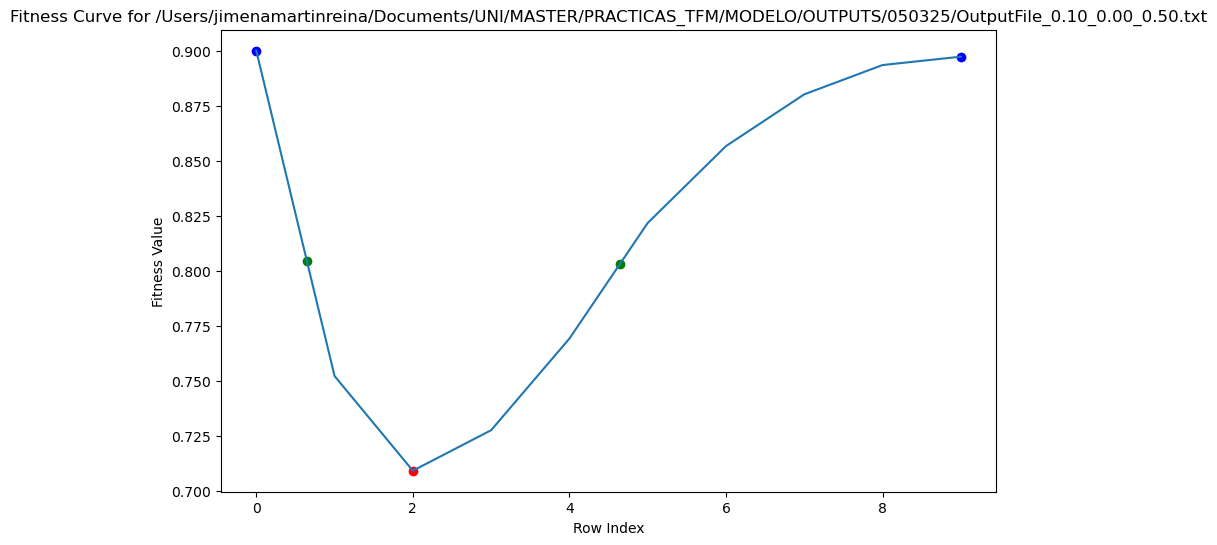

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.77_0.00_0.50.txt
  Minpoint: 6, Value: 0.137
  Max Left: 0, Value Max Left: 0.23
  Max Right: 9, Value Max Right: 0.1551
  Ratio of Left to Right Peak: 1.4829
  Midpoint Left: 0.1835
  Midpoint Right: 0.1461
  Euclidean distance between midpoints: 7.2226


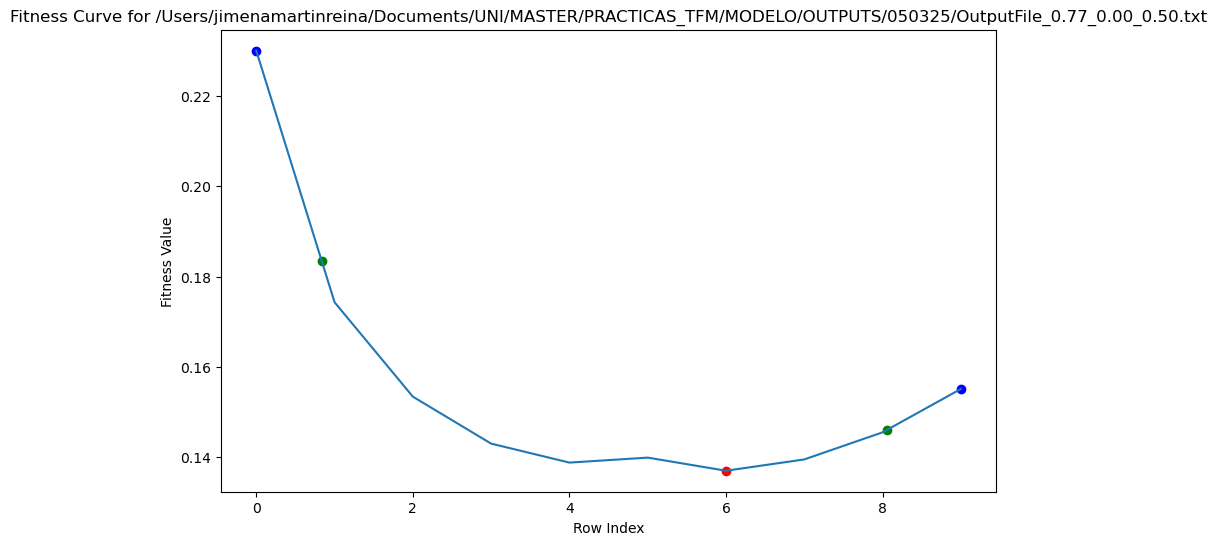

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.77_5.00_0.50.txt
  Minpoint: 7, Value: 0.1189
  Max Left: 1, Value Max Left: 0.5318
  Max Right: 9, Value Max Right: 0.1291
  Ratio of Left to Right Peak: 4.1193
  Midpoint Left: 0.3254
  Midpoint Right: 0.1240
  Euclidean distance between midpoints: 4.6972


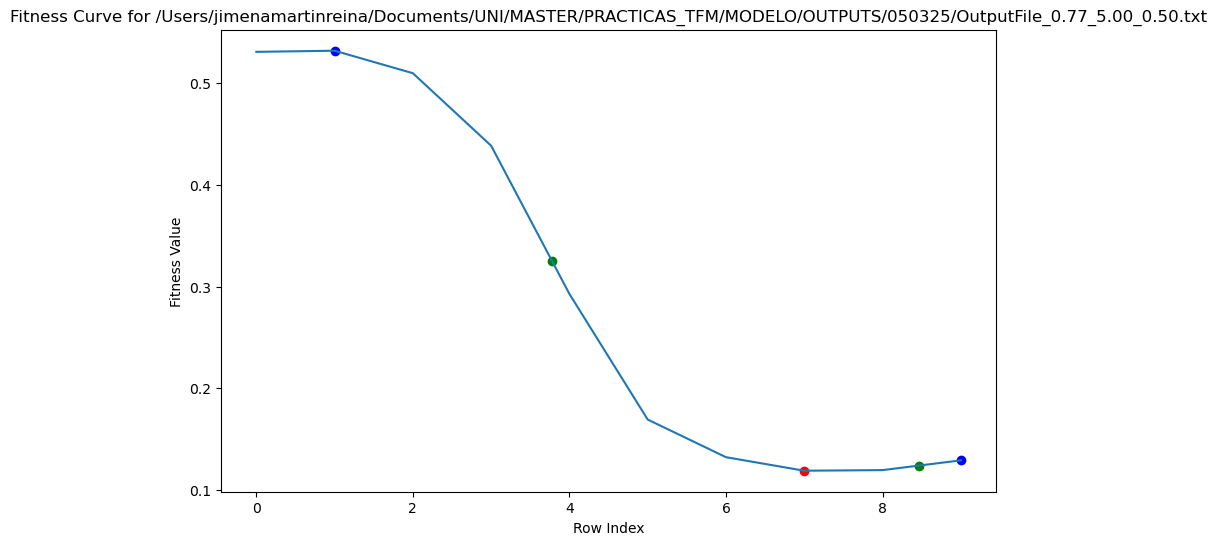

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.10_5.00_0.50.txt
  Minpoint: 6, Value: 0.7052
  Max Left: 2, Value Max Left: 0.949
  Max Right: 9, Value Max Right: 0.8796
  Ratio of Left to Right Peak: 1.0789
  Midpoint Left: 0.8271
  Midpoint Right: 0.7924
  Euclidean distance between midpoints: 2.8920


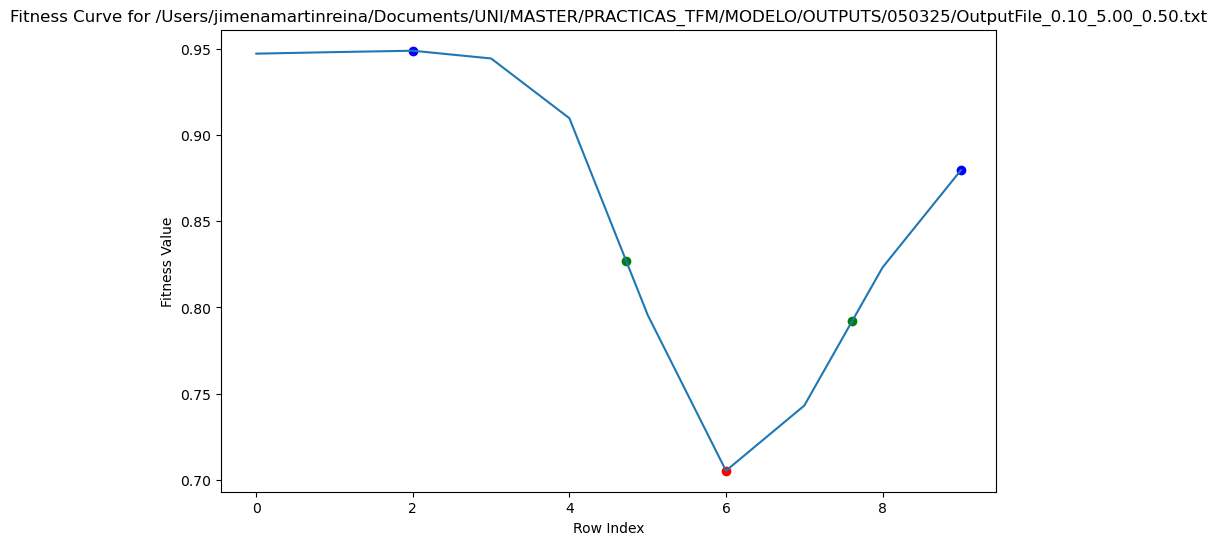

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.77_20.00_0.50.txt
  Minpoint: 9, Value: 0.5234
  Max Left: 6, Value Max Left: 0.9424
  Max Right: None (0, 0)
  Ratio of Left to Right Peak: 0.0000
  Midpoints not calculated (there is not right maximum).


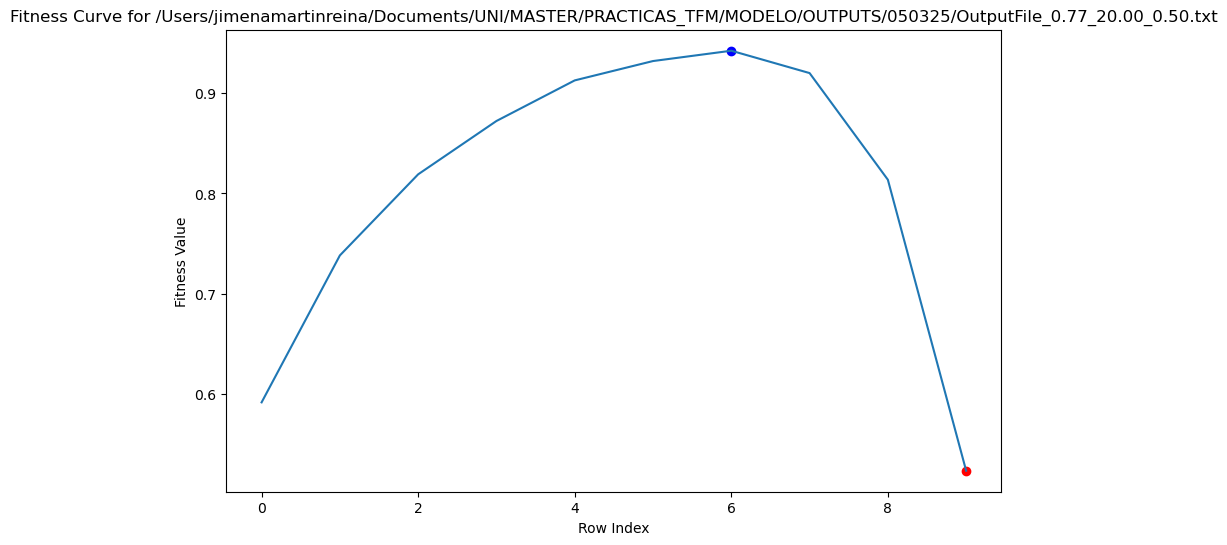

File: /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/OutputFile_0.10_20.00_0.50.txt
  Minpoint: 9, Value: 0.8823
  Max Left: 6, Value Max Left: 0.997
  Max Right: None (0, 0)
  Ratio of Left to Right Peak: 0.0000
  Midpoints not calculated (there is not right maximum).


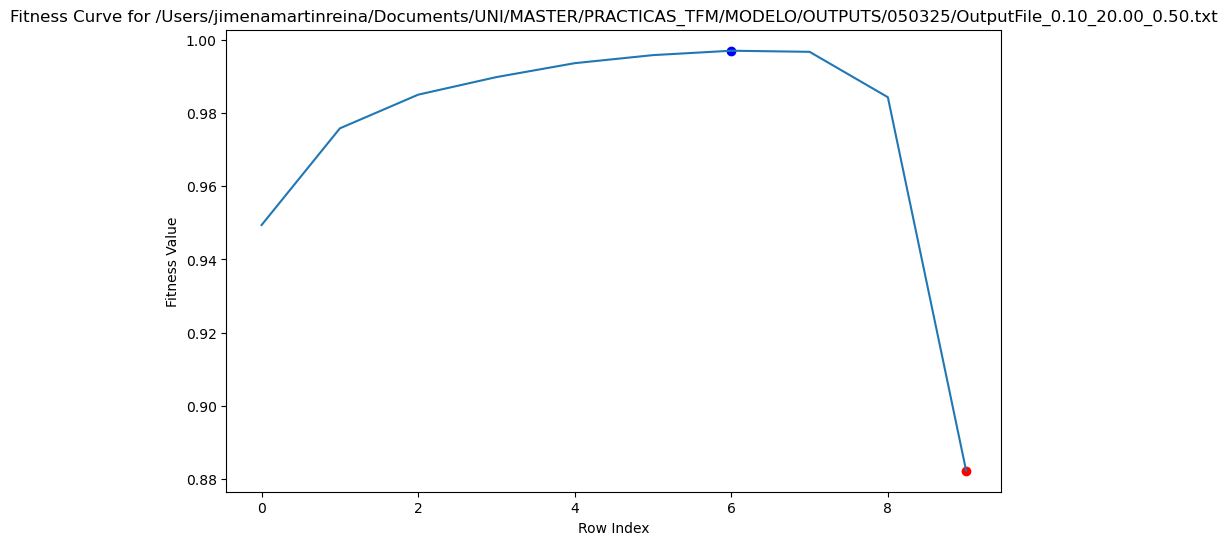

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np
import math

# Function to calculate peaks and minimum
def calculate_peak_ratio_including_endpoints(file_path):
    # Load file
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    # Minimum
    min_point = fitness.idxmin()
    min_value = fitness[min_point]
    # Maxima
    middle_peaks, _ = find_peaks(fitness, distance=10)
    all_peaks = list(middle_peaks) + [0, len(fitness) - 1]
    left_peaks = [p for p in all_peaks if p <= min_point]
    right_peaks = [p for p in all_peaks if p > min_point]
    left_peak = max(left_peaks, key=lambda x: fitness[x]) if left_peaks else None
    # The right maximum may not exist, in that case we define it as 0
    if right_peaks:
        right_peak = max(right_peaks, key=lambda x: fitness[x])
        right_peak_value = fitness[right_peak]
    else:
        right_peak, right_peak_value = 0, 0
    # Ratio may not exist, in that case we define it as 0
    ratio = fitness[left_peak] / right_peak_value if right_peak_value != 0 else 0
    return min_point, ratio, left_peak, right_peak, fitness[left_peak], right_peak_value

for file_path in file_paths:
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    x_values = np.arange(len(fitness))
    min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)
    # Points to graph
    peaks_x = [left_peak]
    peaks_y = [left_peak_value]
    # Add the possible right peaks
    if right_peak_value != 0:
        peaks_x.append(right_peak)
        peaks_y.append(right_peak_value)
    # Calculate both midpoints only when there are both maxima
    if right_peak_value != 0:
        midpoint_left = (fitness[min_point] + left_peak_value) / 2
        midpoint_right = (fitness[min_point] + right_peak_value) / 2
   # Find the indices of midpoints using interpolation
        midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
        midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None
    # Calculate Euclidean distance between midpoints
        euclidean_distance = math.dist([midpoint_left_index, midpoint_left], [midpoint_right_index, midpoint_right])
    else:
        midpoint_left = midpoint_right = midpoint_left_index = midpoint_right_index = euclidean_distance = 0

    # Print results
    print(f"File: {file_path}")
    print(f"  Minpoint: {min_point}, Value: {fitness[min_point]}")
    print(f"  Max Left: {left_peak}, Value Max Left: {left_peak_value}")
    if right_peak_value == 0:
        print(f"  Max Right: None (0, 0)")
    else:
        print(f"  Max Right: {right_peak}, Value Max Right: {right_peak_value}")

    print(f"  Ratio of Left to Right Peak: {ratio:.4f}")
    if right_peak_value != 0:
        print(f"  Midpoint Left: {midpoint_left:.4f}")
        print(f"  Midpoint Right: {midpoint_right:.4f}")
        print(f"  Euclidean distance between midpoints: {euclidean_distance:.4f}")
    else:
        print("  Midpoints not calculated (there is not right maximum).")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(fitness, label=f'{file_path} Fitness')
    # Minimum and peaks
    plt.scatter(min_point, fitness[min_point], color='red', label='Minimum')
    plt.scatter(peaks_x, peaks_y, color='blue', label='Peaks')
    # If there is both peaks, graph also the midpoints
    if right_peak_value != 0:
        plt.scatter(midpoint_left_index, midpoint_left, color='green', label='Midpoint Left')
        plt.scatter(midpoint_right_index, midpoint_right, color='green', label='Midpoint Right')
    plt.title(f"Fitness Curve for {file_path}")
    plt.xlabel("Row Index")
    plt.ylabel("Fitness Value")
    #plt.legend()
    plt.show()

### Using effective average to calculate the proportion of endemic-target spacers

In [68]:
# Initialize lists to store the beta values for each file
endemicBetas = []
epidemicBetas = []
betas = []

# Iterate over the dictionary to collect the 'endemicBeta', 'epidemicBeta', and 'beta' columns
for key, data in data_dict.items():
    endemicBetas.append(data['endemicBeta'])
    epidemicBetas.append(data['epidemicBeta'])
    betas.append(data['beta'])

# Keep results of fE (proportion of endemic-virus-target spacers in each position of the array)
fEs = []

# Calculate fE for each file
for i in range(len(data_dict)): 
    fE = (betas[i] - epidemicBetas[i]) / (endemicBetas[i] - epidemicBetas[i])
    fEs.append(fE)
#    print(f"fE for {list(data_dict.keys())[i]}:\n {fE}") #to verify results

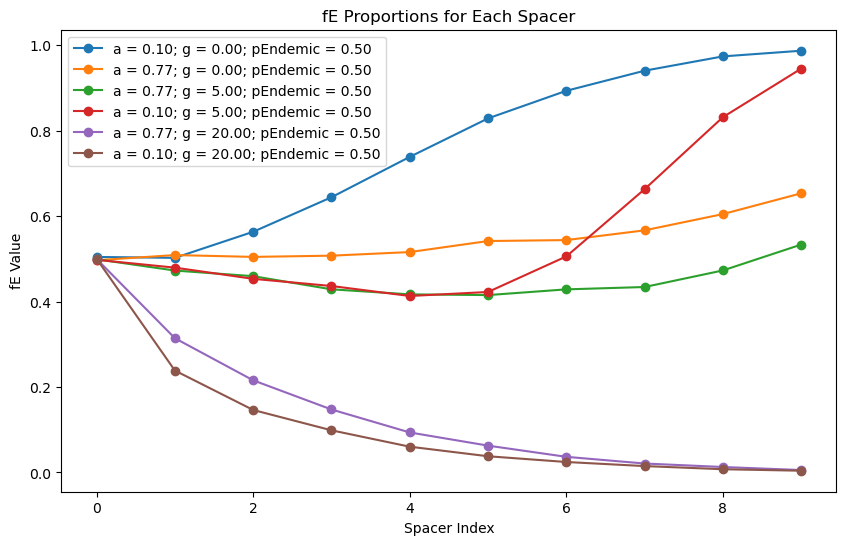

In [69]:
# Plot the fE results for each file
plt.figure(figsize=(10, 6))
for i in range(len(fEs)):
    plt.plot(fEs[i], label= extract_label(list(data_dict.keys())[i]), marker='o')

plt.title("fE Proportions for Each Spacer")
plt.xlabel("Spacer Index")
plt.ylabel("fE Value")
plt.legend()
plt.show()

### References
https://stackoverflow.com/questions/59163774/python-how-to-find-and-visually-mark-the-local-minima-of-a-sequence

https://www.w3schools.com/python/ref_math_dist.asp --> Euclidean distance between two points
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html